In [ ]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# ============================================================
# Directions
# ============================================================
N, E, S, W = 0, 1, 2, 3
DIRS = {N: (-1, 0), E: (0, 1), S: (1, 0), W: (0, -1)}
OPP = {N: S, E: W, S: N, W: E}

# 0=NE, 1=ES, 2=SW, 3=WN
ORIENTS = [
    (N, E),
    (E, S),
    (S, W),
    (W, N),
]
ORIENT_NAMES = ["NE", "ES", "SW", "WN"]

BLUE = np.zeros((4, 4), dtype=np.int8)
for o, ds in enumerate(ORIENTS):
    for d in ds:
        BLUE[o, d] = 1

# ============================================================


# ============================================================
# Type-3 and Type-4 plaquettes
# 0=NE, 1=ES, 2=SW, 3=WN(=NW)
# ============================================================

TYPE3_BASE = np.array([
    [0, 3],
    [1, 2]
], dtype=np.int8)

TYPE4_BASE = np.array([
    [0, 3],
    [2, 1]
], dtype=np.int8)
TYPE5_BASE = np.array([
    [3, 0],
    [2, 1]
], dtype=np.int8)

def rotate_block_cw(block):
    new = np.empty_like(block)
    for i in range(2):
        for j in range(2):
            oi, oj = 1 - j, i
            new[i, j] = (block[oi, oj] + 1) % 4
    return new

def unique_rotations(block):
    out = []
    cur = block.copy()
    for _ in range(4):
        if not any(np.array_equal(cur, x) for x in out):
            out.append(cur.copy())
        cur = rotate_block_cw(cur)
    return out

PLAQUETTE_PATTERNS = {
    "type3": unique_rotations(TYPE3_BASE),
    "type4": unique_rotations(TYPE4_BASE),
    "type5": unique_rotations(TYPE5_BASE),
}

# ============================================================
# Energy with periodic boundary conditions
# ============================================================
def total_mismatch_energy(cfg):
    # PBC via np.roll
    e_h = np.sum(BLUE[cfg, E] ^ BLUE[np.roll(cfg, -1, axis=1), W])
    e_v = np.sum(BLUE[cfg, S] ^ BLUE[np.roll(cfg, -1, axis=0), N])
    return int(e_h + e_v)

def local_delta(cfg, i, j, new_o):
    old_o = cfg[i, j]
    if new_o == old_o:
        return 0

    Lx, Ly = cfg.shape
    de = 0
    for d, (di, dj) in DIRS.items():
        ni, nj = (i + di) % Lx, (j + dj) % Ly  # PBC
        before = BLUE[old_o, d] ^ BLUE[cfg[ni, nj], OPP[d]]
        after  = BLUE[new_o, d] ^ BLUE[cfg[ni, nj], OPP[d]]
        de += after - before
    return int(de)

# ============================================================
# Monte Carlo annealing
# ============================================================
def simulated_annealing(L=16, seed=0, n_temp=80, sweeps_per_temp=20):
    if L % 2 != 0:
        raise ValueError("Use even L for a clean 2x2 partition on a periodic lattice.")

    rng = random.Random(seed)
    cfg = np.array([[rng.randrange(4) for _ in range(L)] for _ in range(L)], dtype=np.int8)

    temps = np.geomspace(3.0, 0.005, n_temp)

    for T in temps:
        for _ in range(sweeps_per_temp * L * L):
            i = rng.randrange(L)
            j = rng.randrange(L)
            old = cfg[i, j]
            new = (old + rng.randrange(1, 4)) % 4

            de = local_delta(cfg, i, j, new)
            if de <= 0 or rng.random() < math.exp(-de / T):
                cfg[i, j] = new

    improved = True
    while improved:
        improved = False
        for i in range(L):
            for j in range(L):
                old = cfg[i, j]
                best = old
                best_de = 0
                for k in range(1, 4):
                    new = (old + k) % 4
                    de = local_delta(cfg, i, j, new)
                    if de < best_de:
                        best_de = de
                        best = new
                if best != old:
                    cfg[i, j] = best
                    improved = True

    return cfg

# ============================================================
# 2x2 block extraction with PBC
# ============================================================
def block_2x2(cfg, i, j):
    Lx, Ly = cfg.shape
    return np.array([
        [cfg[i % Lx, j % Ly],         cfg[i % Lx, (j + 1) % Ly]],
        [cfg[(i + 1) % Lx, j % Ly],   cfg[(i + 1) % Lx, (j + 1) % Ly]]
    ], dtype=np.int8)

def detect_block_type(block, pattern_dict):
    """
    Return list of all matching type names.
    Usually length 0 or 1, but keep it general.
    """
    hits = []
    for name, patterns in pattern_dict.items():
        if any(np.array_equal(block, patt) for patt in patterns):
            hits.append(name)
    return hits

def find_plaquettes_in_partition(cfg, offset=(0, 0), pattern_dict=None):
    """
    Non-overlapping 2x2 scan on one periodic partition.
    Detects type3, type4, type5 simultaneously.
    """
    if pattern_dict is None:
        pattern_dict = PLAQUETTE_PATTERNS

    Lx, Ly = cfg.shape
    if Lx % 2 != 0 or Ly % 2 != 0:
        raise ValueError("Both lattice dimensions must be even.")

    oi, oj = offset
    out = {name: [] for name in pattern_dict}
    out["ambiguous"] = []   # if a block matches more than one class

    for i in range(oi, oi + Lx, 2):
        for j in range(oj, oj + Ly, 2):
            b = block_2x2(cfg, i, j)
            matches = detect_block_type(b, pattern_dict)

            if len(matches) == 1:
                out[matches[0]].append((i % Lx, j % Ly))
            elif len(matches) > 1:
                out["ambiguous"].append(((i % Lx, j % Ly), matches))

    return out

def count_all_partitions(cfg, pattern_dict=None):
    if pattern_dict is None:
        pattern_dict = PLAQUETTE_PATTERNS

    out = {}
    for offset in [(0,0), (0,1), (1,0), (1,1)]:
        out[offset] = find_plaquettes_in_partition(cfg, offset=offset, pattern_dict=pattern_dict)
    return out



# ============================================================
# Outgoing-edge scan on one non-overlapping 2x2 partition
# Outgoing edges = number of blue edges on the OUTER boundary
# of the 2x2 block. For a 2x2 block there are 8 boundary edges total.
# ============================================================

OUTGOING_COLORS = {
    0: "tab:green",
    2: "tab:blue",
    4: "tab:orange",
    8: "tab:red",
    "other": "black",   # catches e.g. 6 if it appears
}

OUTGOING_LABELS = {
    0: "0 outgoing",
    2: "2 outgoing",
    4: "4 outgoing",
    8: "8 outgoing",
    "other": "other",
}

def outgoing_edge_count_block(block):
    """
    block is 2x2 array of orientations.
    Count blue edges on the outer boundary of the 2x2 block.
    """
    # top boundary
    c = int(BLUE[block[0, 0], N] + BLUE[block[0, 1], N])

    # bottom boundary
    c += int(BLUE[block[1, 0], S] + BLUE[block[1, 1], S])

    # left boundary
    c += int(BLUE[block[0, 0], W] + BLUE[block[1, 0], W])

    # right boundary
    c += int(BLUE[block[0, 1], E] + BLUE[block[1, 1], E])

    return c


def outgoing_boundary_segments(cfg, i, j):
    """
    Return the actual outgoing boundary segments of the 2x2 block with top-left (i,j).
    This is for plotting. Assumes the displayed partition is chosen so that the 2x2
    blocks do not wrap in the display; use offset=(0,0) for clean plotting.
    """
    Lx, Ly = cfg.shape
    i0, j0 = i % Lx, j % Ly
    b = block_2x2(cfg, i0, j0)

    segs = []

    # top-left cell: (i,j)
    # top-right cell: (i,j+1)
    # bottom-left cell: (i+1,j)
    # bottom-right cell: (i+1,j+1)

    # top boundary
    if BLUE[b[0, 0], N]:
        segs.append(((j,   i),   (j+1, i)))
    if BLUE[b[0, 1], N]:
        segs.append(((j+1, i),   (j+2, i)))

    # bottom boundary
    if BLUE[b[1, 0], S]:
        segs.append(((j,   i+2), (j+1, i+2)))
    if BLUE[b[1, 1], S]:
        segs.append(((j+1, i+2), (j+2, i+2)))

    # left boundary
    if BLUE[b[0, 0], W]:
        segs.append(((j, i),   (j, i+1)))
    if BLUE[b[1, 0], W]:
        segs.append(((j, i+1), (j, i+2)))

    # right boundary
    if BLUE[b[0, 1], E]:
        segs.append(((j+2, i),   (j+2, i+1)))
    if BLUE[b[1, 1], E]:
        segs.append(((j+2, i+1), (j+2, i+2)))

    return segs


def scan_outgoing_partition(cfg, offset=(0, 0)):
    """
    Scan one non-overlapping 2x2 partition on the periodic lattice.
    Returns positions grouped by outgoing-edge count.
    """
    Lx, Ly = cfg.shape
    if Lx % 2 != 0 or Ly % 2 != 0:
        raise ValueError("Both lattice dimensions must be even.")

    oi, oj = offset
    out = {0: [], 2: [], 4: [], 8: [], "other": []}

    for i in range(oi, oi + Lx, 2):
        for j in range(oj, oj + Ly, 2):
            b = block_2x2(cfg, i, j)
            n_out = outgoing_edge_count_block(b)
            key = n_out if n_out in [0, 2, 4, 8] else "other"
            out[key].append((i % Lx, j % Ly))

    return out


def scan_outgoing_all_partitions(cfg):
    """
    Same outgoing-edge scan for all four periodic 2x2 partitions.
    """
    out = {}
    for offset in [(0,0), (0,1), (1,0), (1,1)]:
        out[offset] = scan_outgoing_partition(cfg, offset=offset)
    return out


def draw_outgoing_partition(cfg, offset=(0, 0), figsize=(8, 8)):
    """
    Plot a chosen non-overlapping 2x2 partition and classify each block
    by outgoing-edge count.

    For clean box drawing, use offset=(0,0). The scan itself is periodic for any offset.
    """
    Lx, Ly = cfg.shape
    if offset != (0, 0):
        raise ValueError("Use offset=(0,0) for the displayed partition. The scan itself works for all offsets.")

    scan = scan_outgoing_partition(cfg, offset=offset)

    # reverse map: top-left -> class
    class_of = {}
    for key, hits in scan.items():
        for h in hits:
            class_of[h] = key

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_xlim(0, Ly)
    ax.set_ylim(Lx, 0)
    ax.set_xticks(range(Ly + 1))
    ax.set_yticks(range(Lx + 1))
    ax.grid(True, lw=0.5, alpha=0.4)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # draw all particle arms faintly
    for i in range(Lx):
        for j in range(Ly):
            cx, cy = j + 0.5, i + 0.5
            for d in ORIENTS[cfg[i, j]]:
                if d == N:
                    ax.plot([cx, cx], [cy, i], lw=1.2, color="0.75")
                elif d == S:
                    ax.plot([cx, cx], [cy, i + 1], lw=1.2, color="0.75")
                elif d == E:
                    ax.plot([cx, j + 1], [cy, cy], lw=1.2, color="0.75")
                elif d == W:
                    ax.plot([cx, j], [cy, cy], lw=1.2, color="0.75")

    # overlay 2x2 plaquette boxes and outgoing edges
    for i in range(0, Lx, 2):
        for j in range(0, Ly, 2):
            key = class_of[(i, j)]
            color = OUTGOING_COLORS[key]

            # colored 2x2 box
            ax.add_patch(Rectangle((j, i), 2, 2, fill=False, lw=2.2, edgecolor=color))

            # colored outgoing boundary edges
            for (x1, y1), (x2, y2) in outgoing_boundary_segments(cfg, i, j):
                ax.plot([x1, x2], [y1, y2], lw=4, color=color, solid_capstyle="butt")

            # for 0-outgoing blocks, put a small marker so they are obvious
            if key == 0:
                ax.plot(j + 1, i + 1, marker="s", markersize=6, color=color)

    legend_order = [0, 2, 4, 8, "other"]
    handles = []
    for key in legend_order:
        if len(scan[key]) == 0:
            continue
        handles.append(Line2D([0], [0],
                              color=OUTGOING_COLORS[key],
                              lw=3,
                              label=f"{OUTGOING_LABELS[key]}  (count = {len(scan[key])})"))

    ax.legend(handles=handles, loc="upper right", frameon=True)
    ax.set_title("Non-overlapping 2x2 scan: plaquettes grouped by outgoing-edge count")
    plt.tight_layout()
    return fig, ax
# ============================================================
# Visualization
# Boxes are drawn only for one chosen non-overlapping partition
# ============================================================
def draw_cfg(cfg, type_hits=None, figsize=(7, 7)):
    """
    type_hits = dict like:
      {
        "type3": [(i,j), ...],
        "type4": [(i,j), ...],
        "type5": [(i,j), ...]
      }
    """
    if type_hits is None:
        type_hits = {"type3": [], "type4": [], "type5": []}

    Lx, Ly = cfg.shape

    hitsets = {k: set(v) for k, v in type_hits.items()}

    styles = {
        "type3": dict(lw=2.2, linestyle="-"),
        "type4": dict(lw=2.2, linestyle="-"),
        "type5": dict(lw=2.2, linestyle="-"),
    }

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_xlim(0, Ly)
    ax.set_ylim(Lx, 0)
    ax.set_xticks(range(Ly + 1))
    ax.set_yticks(range(Lx + 1))
    ax.grid(True, lw=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    for i in range(Lx):
        for j in range(Ly):
            cx, cy = j + 0.5, i + 0.5
            for d in ORIENTS[cfg[i, j]]:
                if d == N:
                    ax.plot([cx, cx], [cy, i], lw=2)
                elif d == S:
                    ax.plot([cx, cx], [cy, i + 1], lw=2)
                elif d == E:
                    ax.plot([cx, j + 1], [cy, cy], lw=2)
                elif d == W:
                    ax.plot([cx, j], [cy, cy], lw=2)

    # overlay boxes after arms
    for tname, posset in hitsets.items():
        style = styles[tname]
        for (i, j) in posset:
            ax.add_patch(plt.Rectangle((j, i), 2, 2, fill=False, **style))

    handles = [
        Line2D([0], [0], color="black", lw=2.2, label="type 3"),
        Line2D([0], [0], color="black", lw=2.2,label="type 4"),
        Line2D([0], [0], color="black", lw=2.2,  label="type 5"),
    ]
    #ax.legend(handles=handles, loc="upper right", frameon=True)
    #ax.set_title("Solid: type 3, dashed: type 4, dotted: type 5")
    plt.tight_layout()
    return fig, ax
# ============================================================
# Coarse-grained plaquette field and strip order parameters
# +1 if plaquette is type3/type4/type5, -1 otherwise
# One value per non-overlapping 2x2 plaquette in a chosen partition
# ============================================================

def plaquette_order_grid(cfg, offset=(0, 0), positive_types=("type3", "type4", "type5"), pattern_dict=None):
    """
    Build a coarse-grained plaquette field on one non-overlapping 2x2 partition.

    Returns
    -------
    grid : (Lx/2, Ly/2) array with entries +1 or -1
    row_pos : list of top-left lattice-row coordinates for each plaquette row
    col_pos : list of top-left lattice-col coordinates for each plaquette col
    labels : object array of same shape, storing matched type names
    """
    if pattern_dict is None:
        pattern_dict = PLAQUETTE_PATTERNS

    Lx, Ly = cfg.shape
    if Lx % 2 != 0 or Ly % 2 != 0:
        raise ValueError("Both lattice dimensions must be even.")

    oi, oj = offset
    row_pos = [(i % Lx) for i in range(oi, oi + Lx, 2)]
    col_pos = [(j % Ly) for j in range(oj, oj + Ly, 2)]

    nx = len(row_pos)
    ny = len(col_pos)

    grid = np.empty((nx, ny), dtype=np.int8)
    labels = np.empty((nx, ny), dtype=object)

    posset = set(positive_types)

    for a, i in enumerate(range(oi, oi + Lx, 2)):
        for b, j in enumerate(range(oj, oj + Ly, 2)):
            block = block_2x2(cfg, i, j)
            matches = detect_block_type(block, pattern_dict)

            # +1 if any of the positive types is present, else -1
            grid[a, b] = 1 if any(m in posset for m in matches) else -1
            labels[a, b] = tuple(matches)

    return grid, row_pos, col_pos, labels


def strip_order_parameters(order_grid, normalize=True):
    """
    Vertical strips: fixed plaquette-column, traverse all plaquette rows.
    Horizontal strips: fixed plaquette-row, traverse all plaquette cols.

    Returns m_vert[n], m_horz[n].
    If normalize=True, divide by strip length so values lie in [-1, 1].
    Otherwise return raw sums.
    """
    if normalize:
        m_vert = order_grid.mean(axis=0)   # one value per plaquette-column
        m_horz = order_grid.mean(axis=1)   # one value per plaquette-row
    else:
        m_vert = order_grid.sum(axis=0)
        m_horz = order_grid.sum(axis=1)

    return m_vert, m_horz


def draw_order_heatmap(order_grid, offset=(0, 0), figsize=(6, 6)):
    """
    Heatmap of the coarse plaquette field.
    +1 = type3/4/5
    -1 = anything else
    """
    nx, ny = order_grid.shape

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(order_grid, origin="upper", vmin=-1, vmax=1, interpolation="none")

    ax.set_xticks(np.arange(ny))
    ax.set_yticks(np.arange(nx))
    ax.set_xlabel("plaquette-column index")
    ax.set_ylabel("plaquette-row index")
    #ax.set_title(f"Plaquette field on 2x2 partition, offset={offset}")

    # optional values inside cells
    for i in range(nx):
        for j in range(ny):
            ax.text(j, i, f"{order_grid[i, j]:d}", ha="center", va="center")

    #cbar = fig.colorbar(im, ax=ax)
    #cbar.set_ticks([-1, 1])
    #cbar.set_ticklabels(["other", "type3/4/5"])

    plt.tight_layout()
    return fig, ax


def draw_vertical_strip_profile(m_vert, normalize=True, figsize=(7, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(np.arange(len(m_vert)), m_vert, marker="o")
    ax.axhline(0, lw=1)
    ax.set_xlabel("vertical strip index n")
    ax.set_ylabel("m_vert(n)" if normalize else "M_vert(n)")
    ax.set_title("Vertical strip order parameter")
    plt.tight_layout()
    return fig, ax


def draw_horizontal_strip_profile(m_horz, normalize=True, figsize=(7, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(np.arange(len(m_horz)), m_horz, marker="o")
    ax.axhline(0, lw=1)
    ax.set_xlabel("horizontal strip index n")
    ax.set_ylabel("m_horz(n)" if normalize else "M_horz(n)")
    ax.set_title("Horizontal strip order parameter")
    plt.tight_layout()
    return fig, ax


In [45]:
if __name__ == "__main__":
    L = 48
    seed = 1000
    chosen_offset = (0, 0)

    cfg = simulated_annealing(L=L, seed=seed,sweeps_per_temp=45)
    E_mis = total_mismatch_energy(cfg)

    print("L =", L)
    print("seed =", seed)
    print("mismatch energy =", E_mis)
    print("perfect tiling =", (E_mis == 0))
    print()

    # --- existing scans ---
    all_counts = count_all_partitions(cfg)
    for offset, res in all_counts.items():
        print(f"offset {offset}:")
        print(f"  type-3 count = {len(res['type3'])}")
        print(f"  type-4 count = {len(res['type4'])}")
        print(f"  type-5 count = {len(res['type5'])}")
        print(f"  ambiguous    = {len(res['ambiguous'])}")
        print()

    out_all = scan_outgoing_all_partitions(cfg)
    for offset, res in out_all.items():
        print(f"outgoing scan, offset {offset}:")
        for key in [0, 2, 4, 8, "other"]:
            print(f"  {OUTGOING_LABELS[key]}: {len(res[key])}")
        print()


L = 48
seed = 1000
mismatch energy = 0
perfect tiling = True

offset (0, 0):
  type-3 count = 62
  type-4 count = 142
  type-5 count = 30
  ambiguous    = 0

offset (0, 1):
  type-3 count = 58
  type-4 count = 170
  type-5 count = 42
  ambiguous    = 0

offset (1, 0):
  type-3 count = 58
  type-4 count = 118
  type-5 count = 20
  ambiguous    = 0

offset (1, 1):
  type-3 count = 62
  type-4 count = 146
  type-5 count = 28
  ambiguous    = 0

outgoing scan, offset (0, 0):
  0 outgoing: 28
  2 outgoing: 146
  4 outgoing: 230
  8 outgoing: 30
  other: 142

outgoing scan, offset (0, 1):
  0 outgoing: 20
  2 outgoing: 118
  4 outgoing: 226
  8 outgoing: 42
  other: 170

outgoing scan, offset (1, 0):
  0 outgoing: 42
  2 outgoing: 170
  4 outgoing: 226
  8 outgoing: 20
  other: 118

outgoing scan, offset (1, 1):
  0 outgoing: 30
  2 outgoing: 142
  4 outgoing: 230
  8 outgoing: 28
  other: 146



chosen offset = (0, 0)
plaquette-row top-left coordinates    = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46]
plaquette-column top-left coordinates = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46]

normalized vertical profile m_vert(n) = [-0.58333333 -0.58333333  1.         -0.58333333  1.         -0.58333333
  1.         -0.58333333 -0.58333333 -0.58333333 -0.58333333 -0.58333333
 -0.58333333  1.         -0.58333333 -0.58333333 -0.58333333 -0.58333333
 -0.58333333 -0.58333333 -0.58333333  1.         -0.58333333  1.        ]
normalized horizontal profile m_horz(n) = [-0.5 -0.5 -0.5 -0.5 -0.5  1.  -0.5 -0.5 -0.5 -0.5  1.  -0.5 -0.5  1.
 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5  1.   1.  -0.5 -0.5]

raw vertical sums M_vert(n) = [-14 -14  24 -14  24 -14  24 -14 -14 -14 -14 -14 -14  24 -14 -14 -14 -14
 -14 -14 -14  24 -14  24]
raw horizontal sums M_horz(n) = [-12 -12 -12 -12 -12  24 -12 -12 -12 -12  24 -12 -12 

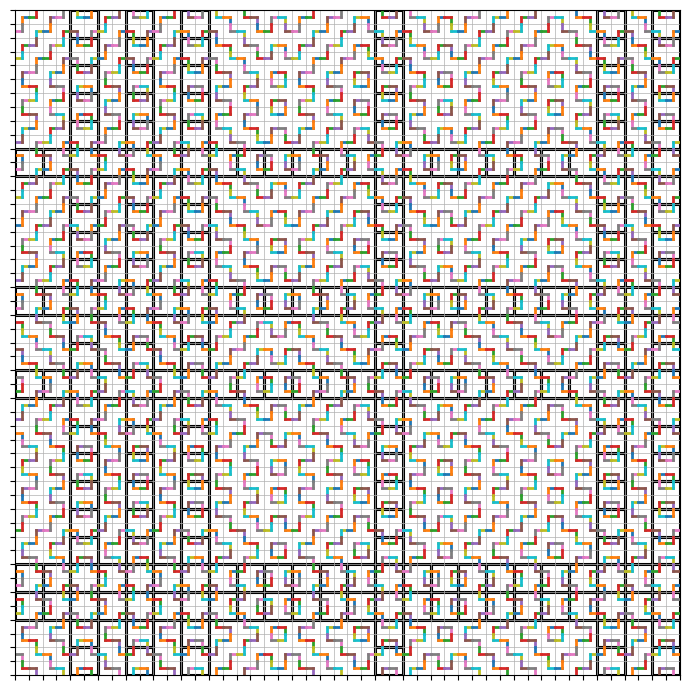

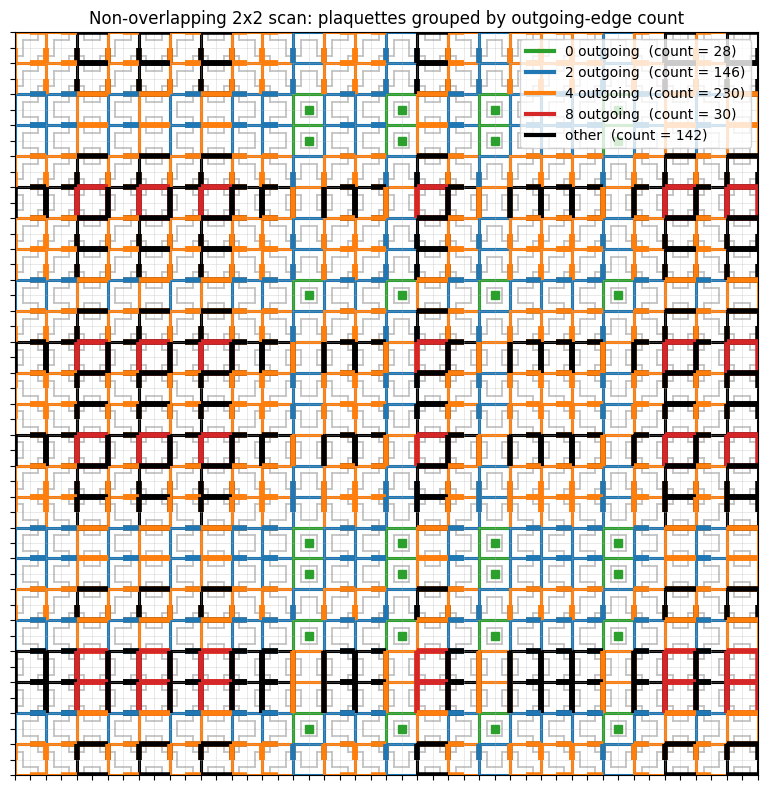

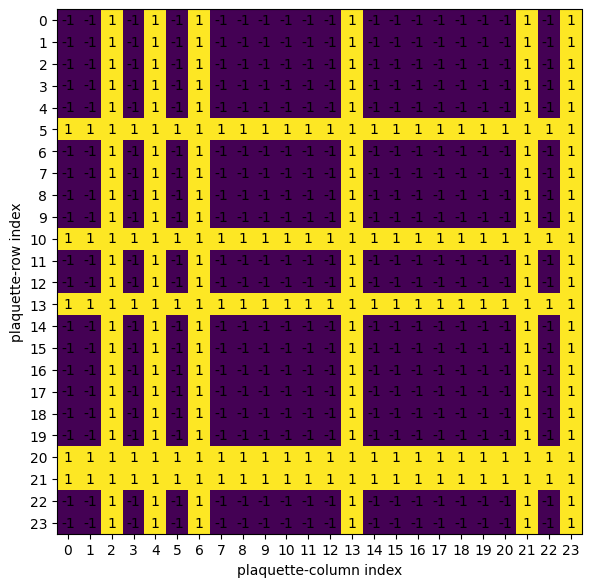

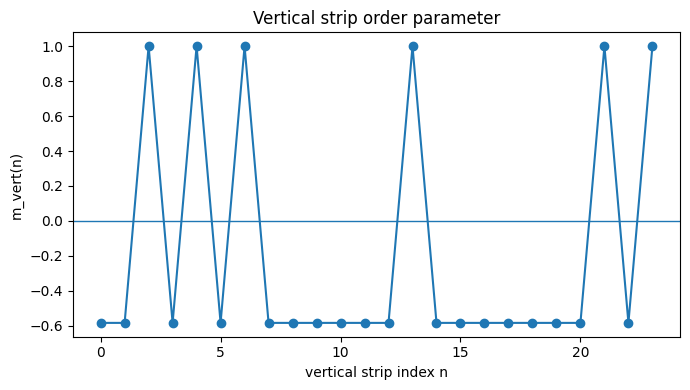

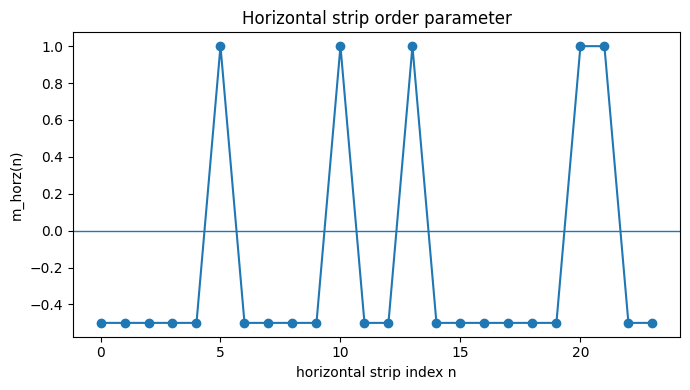

In [46]:

# --- existing plots ---
fig1, ax1 = draw_cfg(
    cfg,
    type_hits={
        "type3": all_counts[chosen_offset]["type3"],
        "type4": all_counts[chosen_offset]["type4"],
        "type5": all_counts[chosen_offset]["type5"],
    },
    figsize=(7, 7),
)

fig2, ax2 = draw_outgoing_partition(cfg, offset=chosen_offset, figsize=(8, 8))

# --- new coarse-grained order parameter field ---
order_grid, row_pos, col_pos, labels = plaquette_order_grid(
    cfg,
    offset=chosen_offset,
    positive_types=("type3", "type4", "type5"),
)

# normalized strip order parameters in [-1, 1]
m_vert, m_horz = strip_order_parameters(order_grid, normalize=True)

# raw sums if you want counts instead
M_vert, M_horz = strip_order_parameters(order_grid, normalize=False)

print("chosen offset =", chosen_offset)
print("plaquette-row top-left coordinates    =", row_pos)
print("plaquette-column top-left coordinates =", col_pos)
print()

print("normalized vertical profile m_vert(n) =", m_vert)
print("normalized horizontal profile m_horz(n) =", m_horz)
print()

print("raw vertical sums M_vert(n) =", M_vert)
print("raw horizontal sums M_horz(n) =", M_horz)
print()

fig3, ax3 = draw_order_heatmap(order_grid, offset=chosen_offset, figsize=(6, 6))
fig4, ax4 = draw_vertical_strip_profile(m_vert, normalize=True, figsize=(7, 4))
fig5, ax5 = draw_horizontal_strip_profile(m_horz, normalize=True, figsize=(7, 4))

plt.show()

Accepted ground state   1/50  seed=1000
Accepted ground state   2/50  seed=1001
Accepted ground state   3/50  seed=1003
Accepted ground state   4/50  seed=1004
Accepted ground state   5/50  seed=1005
Accepted ground state   6/50  seed=1007
Accepted ground state   7/50  seed=1008
Accepted ground state   8/50  seed=1009
Accepted ground state   9/50  seed=1010
Accepted ground state  10/50  seed=1011
Accepted ground state  11/50  seed=1012
Accepted ground state  12/50  seed=1013
Accepted ground state  13/50  seed=1015
Accepted ground state  14/50  seed=1016
Accepted ground state  15/50  seed=1017
Accepted ground state  16/50  seed=1018
Accepted ground state  17/50  seed=1019
Accepted ground state  18/50  seed=1020
Accepted ground state  19/50  seed=1021
Accepted ground state  20/50  seed=1022
Accepted ground state  21/50  seed=1023
Accepted ground state  22/50  seed=1024
Accepted ground state  23/50  seed=1025
Accepted ground state  24/50  seed=1026
Accepted ground state  25/50  seed=1027


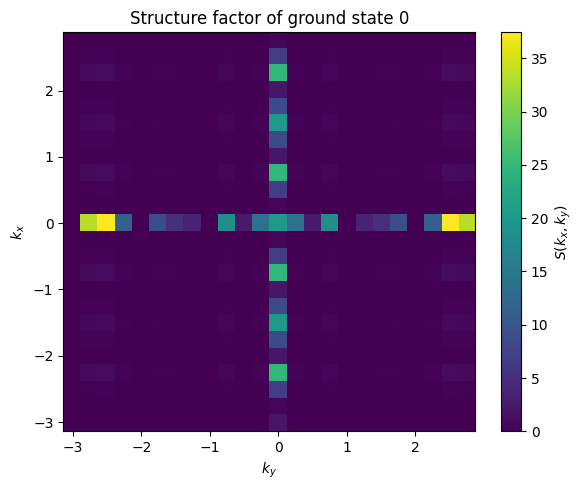

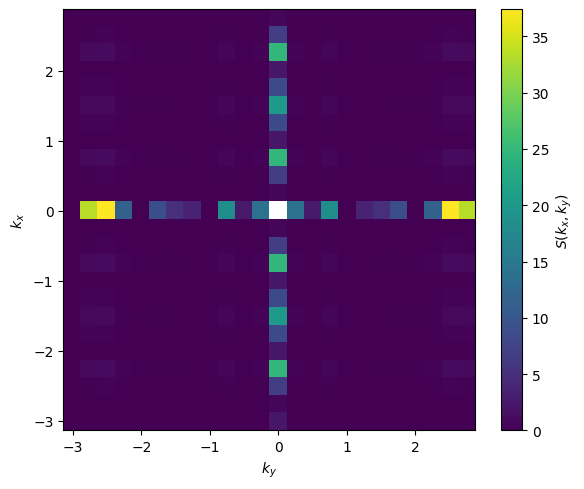

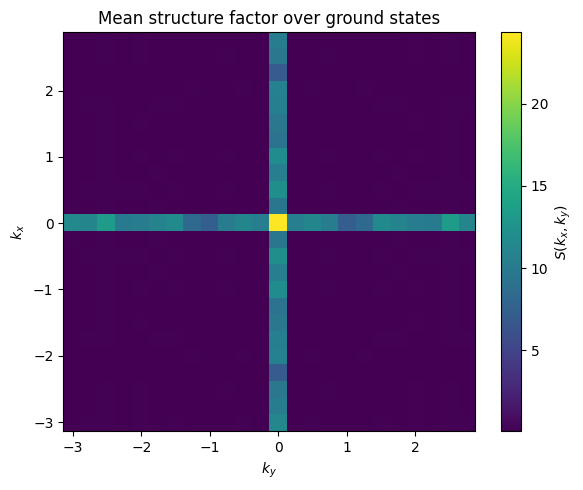

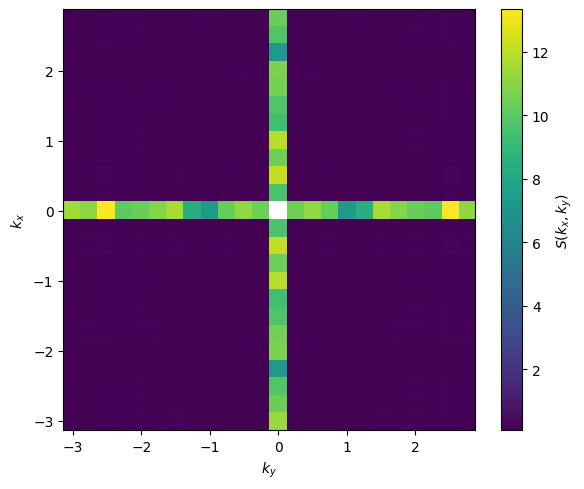

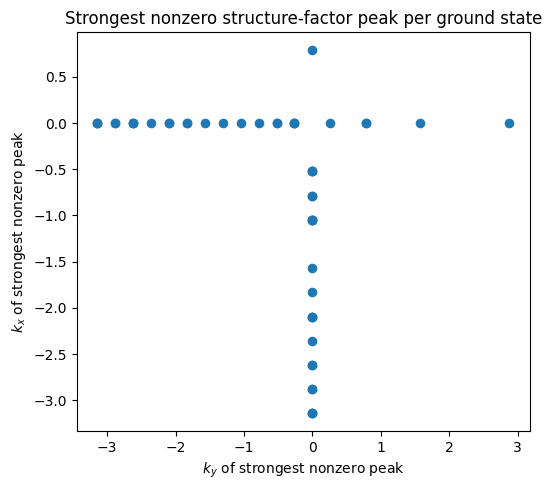


Done.
L = 48
Plaquette lattice size = (24, 24)
Accepted ground states = 50 out of 54 attempts
Saved raw arrays to: ground_states_with_structure_factors.npz
Saved vertical strip CSV to: vertical_strip_magnetizations.csv
Saved horizontal strip CSV to: horizontal_strip_magnetizations.csv
Saved peak summary CSV to: structure_factor_peak_summary.csv

First 10 peak summaries:
state= 0 seed=1000 peak=(kx=+0.000000, ky=-2.617994) S_peak=37.424176 vertical_weight=270.750000 horizontal_weight=213.750000
state= 1 seed=1001 peak=(kx=+0.000000, ky=-2.617994) S_peak=31.100423 vertical_weight=330.555556 horizontal_weight=160.555556
state= 2 seed=1003 peak=(kx=+0.000000, ky=-3.141593) S_peak=84.027778 vertical_weight=453.750000 horizontal_weight=68.750000
state= 3 seed=1004 peak=(kx=+0.000000, ky=-1.832596) S_peak=65.977739 vertical_weight=300.000000 horizontal_weight=180.000000
state= 4 seed=1005 peak=(kx=-2.879793, ky=+0.000000) S_peak=83.605698 vertical_weight=142.222222 horizontal_weight=355.5555

In [47]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import csv
from pathlib import Path

# ============================================================
# Directions and particle orientations
# ============================================================
N, E, S, W = 0, 1, 2, 3
DIRS = {N: (-1, 0), E: (0, 1), S: (1, 0), W: (0, -1)}
OPP = {N: S, E: W, S: N, W: E}

# 0=NE, 1=ES(=SE), 2=SW, 3=WN(=NW)
ORIENTS = [(N, E), (E, S), (S, W), (W, N)]

BLUE = np.zeros((4, 4), dtype=np.int8)
for o, ds in enumerate(ORIENTS):
    for d in ds:
        BLUE[o, d] = 1

# ============================================================
# Plaquette types
# ============================================================
TYPE3_BASE = np.array([[0, 3], [1, 2]], dtype=np.int8)
TYPE4_BASE = np.array([[0, 3], [2, 1]], dtype=np.int8)
TYPE5_BASE = np.array([[3, 0], [2, 1]], dtype=np.int8)

def rotate_block_cw(block):
    new = np.empty_like(block)
    for i in range(2):
        for j in range(2):
            oi, oj = 1 - j, i
            new[i, j] = (block[oi, oj] + 1) % 4
    return new

def unique_rotations(block):
    out = []
    cur = block.copy()
    for _ in range(4):
        if not any(np.array_equal(cur, x) for x in out):
            out.append(cur.copy())
        cur = rotate_block_cw(cur)
    return out

PLAQUETTE_PATTERNS = {
    "type3": unique_rotations(TYPE3_BASE),
    "type4": unique_rotations(TYPE4_BASE),
    "type5": unique_rotations(TYPE5_BASE),
}

# ============================================================
# Energy with periodic boundary conditions
# ============================================================
def total_mismatch_energy(cfg):
    e_h = np.sum(BLUE[cfg, E] ^ BLUE[np.roll(cfg, -1, axis=1), W])
    e_v = np.sum(BLUE[cfg, S] ^ BLUE[np.roll(cfg, -1, axis=0), N])
    return int(e_h + e_v)

def local_delta(cfg, i, j, new_o):
    old_o = cfg[i, j]
    if new_o == old_o:
        return 0

    Lx, Ly = cfg.shape
    de = 0
    for d, (di, dj) in DIRS.items():
        ni, nj = (i + di) % Lx, (j + dj) % Ly
        before = BLUE[old_o, d] ^ BLUE[cfg[ni, nj], OPP[d]]
        after = BLUE[new_o, d] ^ BLUE[cfg[ni, nj], OPP[d]]
        de += after - before
    return int(de)

# ============================================================
# Monte Carlo annealing
# ============================================================
def simulated_annealing(L=16, seed=0, n_temp=80, sweeps_per_temp=20):
    rng = random.Random(seed)
    cfg = np.array([[rng.randrange(4) for _ in range(L)] for _ in range(L)], dtype=np.int8)

    temps = np.geomspace(3.0, 0.005, n_temp)

    for T in temps:
        for _ in range(sweeps_per_temp * L * L):
            i = rng.randrange(L)
            j = rng.randrange(L)
            old = cfg[i, j]
            new = (old + rng.randrange(1, 4)) % 4
            de = local_delta(cfg, i, j, new)

            if de <= 0 or rng.random() < math.exp(-de / T):
                cfg[i, j] = new

    # greedy cleanup
    improved = True
    while improved:
        improved = False
        for i in range(L):
            for j in range(L):
                old = cfg[i, j]
                best = old
                best_de = 0
                for k in range(1, 4):
                    new = (old + k) % 4
                    de = local_delta(cfg, i, j, new)
                    if de < best_de:
                        best_de = de
                        best = new
                if best != old:
                    cfg[i, j] = best
                    improved = True

    return cfg

# ============================================================
# Plaquette detection and binary plaquette field s_mn
# ============================================================
def block_2x2(cfg, i, j):
    Lx, Ly = cfg.shape
    return np.array([
        [cfg[i % Lx, j % Ly],       cfg[i % Lx, (j + 1) % Ly]],
        [cfg[(i + 1) % Lx, j % Ly], cfg[(i + 1) % Lx, (j + 1) % Ly]],
    ], dtype=np.int8)

def detect_block_type(block):
    hits = []
    for name, patterns in PLAQUETTE_PATTERNS.items():
        if any(np.array_equal(block, patt) for patt in patterns):
            hits.append(name)
    return hits

def plaquette_order_grid(cfg, offset=(0, 0), positive_types=("type3", "type4", "type5")):
    """
    Build s_mn on the non-overlapping 2x2 plaquette lattice:
        +1 if plaquette is type 3,4,5
        -1 otherwise
    """
    Lx, Ly = cfg.shape
    if Lx % 2 != 0 or Ly % 2 != 0:
        raise ValueError("Lattice dimensions must be even.")

    oi, oj = offset
    row_pos = [(i % Lx) for i in range(oi, oi + Lx, 2)]
    col_pos = [(j % Ly) for j in range(oj, oj + Ly, 2)]

    grid = np.empty((len(row_pos), len(col_pos)), dtype=np.int8)
    posset = set(positive_types)

    for a, i in enumerate(range(oi, oi + Lx, 2)):
        for b, j in enumerate(range(oj, oj + Ly, 2)):
            block = block_2x2(cfg, i, j)
            matches = detect_block_type(block)
            grid[a, b] = 1 if any(m in posset for m in matches) else -1

    return grid, row_pos, col_pos

def strip_order_parameters(order_grid, normalize=True):
    if normalize:
        m_vert = order_grid.mean(axis=0)
        m_horz = order_grid.mean(axis=1)
    else:
        m_vert = order_grid.sum(axis=0)
        m_horz = order_grid.sum(axis=1)
    return m_vert, m_horz

# ============================================================
# Structure factor
# ============================================================
def structure_factor(grid):
    """
    S(kx, ky) = (1/Np) * |sum_{m,n} s_mn exp[-i(kx m + ky n)]|^2
    computed on the plaquette lattice using FFT.
    Returns the unshifted FFT ordering.
    """
    Nx, Ny = grid.shape
    Np = Nx * Ny
    F = np.fft.fft2(grid)
    S = (np.abs(F) ** 2) / Np
    return S

def shifted_structure_factor(grid):
    return np.fft.fftshift(structure_factor(grid))

def shifted_k_axes(Nx, Ny):
    kx = np.fft.fftshift(2.0 * np.pi * np.fft.fftfreq(Nx))
    ky = np.fft.fftshift(2.0 * np.pi * np.fft.fftfreq(Ny))
    return kx, ky

def mask_zero_mode(S):
    S_plot = S.astype(float).copy()
    cx, cy = S_plot.shape[0] // 2, S_plot.shape[1] // 2
    S_plot[cx, cy] = np.nan
    return S_plot

def axis_weights(S_shifted):
    """
    For stripe diagnosis on shifted S:
      vertical stripes   -> weight on kx=0 row   (vary along y / columns)
      horizontal stripes -> weight on ky=0 col   (vary along x / rows)
    """
    Nx, Ny = S_shifted.shape
    cx, cy = Nx // 2, Ny // 2

    S = S_shifted.copy()
    S[cx, cy] = 0.0

    vertical_weight = np.sum(S[cx, :])     # kx = 0
    horizontal_weight = np.sum(S[:, cy])   # ky = 0
    return vertical_weight, horizontal_weight

def strongest_nonzero_peak(S_shifted, kx, ky):
    S = S_shifted.copy()
    cx, cy = S.shape[0] // 2, S.shape[1] // 2
    S[cx, cy] = -np.inf
    idx = np.unravel_index(np.argmax(S), S.shape)
    return idx, kx[idx[0]], ky[idx[1]], S_shifted[idx]

# ============================================================
# Plot helpers
# ============================================================
def plot_structure_factor(S_shifted, kx, ky, title, outpath=None, mask_zero=False):
    S_plot = mask_zero_mode(S_shifted) if mask_zero else S_shifted

    plt.figure(figsize=(6, 5))
    plt.imshow(
        S_plot,
        origin="lower",
        extent=[ky[0], ky[-1], kx[0], kx[-1]],
        aspect="auto"
    )
    plt.xlabel(r"$k_y$")
    plt.ylabel(r"$k_x$")
    plt.title(title)
    plt.colorbar(label=r"$S(k_x,k_y)$")
    plt.tight_layout()

    if outpath is not None:
        plt.savefig(outpath, dpi=180)
    plt.show()

def plot_peak_scatter(peak_kx, peak_ky, outpath=None):
    plt.figure(figsize=(5.5, 5))
    plt.scatter(peak_ky, peak_kx, s=35)
    plt.xlabel(r"$k_y$ of strongest nonzero peak")
    plt.ylabel(r"$k_x$ of strongest nonzero peak")
    plt.title("Strongest nonzero structure-factor peak per ground state")
    plt.tight_layout()
    if outpath is not None:
        plt.savefig(outpath, dpi=180)
    plt.show()

# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # ---------------------------
    # Parameters
    # ---------------------------
    L = 48
    offset = (0, 0)
    target_ground_states = 50
    attempt_max = 1000
    n_temp = 80
    sweeps_per_temp = 45

    outdir = Path(".")
    outdir.mkdir(parents=True, exist_ok=True)

    # ---------------------------
    # Collect zero-mismatch states
    # ---------------------------
    accepted_seeds = []
    m_vert_list = []
    m_horz_list = []
    grid_list = []

    attempt = 0
    while len(accepted_seeds) < target_ground_states and attempt < attempt_max:
        seed = 1000 + attempt
        cfg = simulated_annealing(
            L=L,
            seed=seed,
            n_temp=n_temp,
            sweeps_per_temp=sweeps_per_temp,
        )

        if total_mismatch_energy(cfg) == 0:
            grid, row_pos, col_pos = plaquette_order_grid(cfg, offset=offset)
            m_vert, m_horz = strip_order_parameters(grid, normalize=True)

            accepted_seeds.append(seed)
            grid_list.append(grid.copy())
            m_vert_list.append(m_vert.copy())
            m_horz_list.append(m_horz.copy())

            print(f"Accepted ground state {len(accepted_seeds):3d}/{target_ground_states}  seed={seed}")

        attempt += 1

    if len(accepted_seeds) < target_ground_states:
        raise RuntimeError(
            f"Only found {len(accepted_seeds)} ground states after {attempt} attempts."
        )

    grid_arr = np.array(grid_list, dtype=np.int8)         # (n_states, 24, 24) for L=48
    m_vert_arr = np.array(m_vert_list, dtype=float)
    m_horz_arr = np.array(m_horz_list, dtype=float)

    # ---------------------------
    # Structure factors
    # ---------------------------
    S_arr = np.array([shifted_structure_factor(g) for g in grid_arr], dtype=float)
    S_mean = np.mean(S_arr, axis=0)

    Nx, Ny = grid_arr.shape[1], grid_arr.shape[2]
    kx, ky = shifted_k_axes(Nx, Ny)

    # ---------------------------
    # Save raw arrays
    # ---------------------------
    npz_path = outdir / "../data/ground_states_with_structure_factors.npz"
    np.savez(
        npz_path,
        L=L,
        offset=np.array(offset),
        accepted_seeds=np.array(accepted_seeds),
        row_pos=np.array(row_pos),
        col_pos=np.array(col_pos),
        m_vert=m_vert_arr,
        m_horz=m_horz_arr,
        plaquette_fields=grid_arr,
        structure_factors=S_arr,
        mean_structure_factor=S_mean,
        kx=kx,
        ky=ky,
    )

    # ---------------------------
    # Save strip CSVs
    # ---------------------------
    csv_vert_path = outdir / "../data/vertical_strip_magnetizations.csv"
    csv_horz_path = outdir / "../data/horizontal_strip_magnetizations.csv"

    with open(csv_vert_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["state_index", "seed"] + [f"strip_{n}" for n in range(m_vert_arr.shape[1])])
        for idx, (seed, row) in enumerate(zip(accepted_seeds, m_vert_arr)):
            writer.writerow([idx, seed] + list(row))

    with open(csv_horz_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["state_index", "seed"] + [f"strip_{n}" for n in range(m_horz_arr.shape[1])])
        for idx, (seed, row) in enumerate(zip(accepted_seeds, m_horz_arr)):
            writer.writerow([idx, seed] + list(row))

    # ---------------------------
    # Peak summary table
    # ---------------------------
    peak_csv_path = outdir / "../data/structure_factor_peak_summary.csv"
    peak_kx = []
    peak_ky = []

    with open(peak_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "state_index",
            "seed",
            "peak_ix",
            "peak_iy",
            "peak_kx",
            "peak_ky",
            "peak_value",
            "vertical_axis_weight",
            "horizontal_axis_weight",
        ])

        for state_idx, (seed, S) in enumerate(zip(accepted_seeds, S_arr)):
            idx, pkx, pky, pval = strongest_nonzero_peak(S, kx, ky)
            wv, wh = axis_weights(S)

            peak_kx.append(pkx)
            peak_ky.append(pky)

            writer.writerow([
                state_idx,
                seed,
                idx[0],
                idx[1],
                pkx,
                pky,
                pval,
                wv,
                wh,
            ])

    # ---------------------------
    # Plots
    # ---------------------------
    plot_structure_factor(
        S_arr[0],
        kx,
        ky,
        title="Structure factor of ground state 0",
        outpath=outdir / "../figures/structure_factor_state0_full.png",
        mask_zero=False,
    )

    plot_structure_factor(
        S_arr[0],
        kx,
        ky,
        title="",
        outpath=outdir / "../figures/structure_factor_state0_masked.png",
        mask_zero=True,
    )

    plot_structure_factor(
        S_mean,
        kx,
        ky,
        title="Mean structure factor over ground states",
        outpath=outdir / "../figures/structure_factor_mean_full.png",
        mask_zero=False,
    )

    plot_structure_factor(
        S_mean,
        kx,
        ky,
        title="",
        outpath=outdir / "../figures/structure_factor_mean_masked.png",
        mask_zero=True,
    )

    plot_peak_scatter(
        np.array(peak_kx),
        np.array(peak_ky),
        outpath=outdir / "../figures/structure_factor_peak_scatter.png",
    )

    # ---------------------------
    # Console summary
    # ---------------------------
    print()
    print("Done.")
    print(f"L = {L}")
    print(f"Plaquette lattice size = ({Nx}, {Ny})")
    print(f"Accepted ground states = {len(accepted_seeds)} out of {attempt} attempts")
    print(f"Saved raw arrays to: {npz_path}")
    print(f"Saved vertical strip CSV to: {csv_vert_path}")
    print(f"Saved horizontal strip CSV to: {csv_horz_path}")
    print(f"Saved peak summary CSV to: {peak_csv_path}")
    print()
    print("First 10 peak summaries:")
    for state_idx, seed in list(enumerate(accepted_seeds))[:10]:
        idx, pkx, pky, pval = strongest_nonzero_peak(S_arr[state_idx], kx, ky)
        wv, wh = axis_weights(S_arr[state_idx])
        print(
            f"state={state_idx:2d} seed={seed:4d} "
            f"peak=(kx={pkx:+.6f}, ky={pky:+.6f}) "
            f"S_peak={pval:.6f} "
            f"vertical_weight={wv:.6f} "
            f"horizontal_weight={wh:.6f}"
        )
        
        
        
        